<a href="https://colab.research.google.com/github/rasikacs23172/mechine-learning-tae/blob/main/Model_3_logisticregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd

# Load the CSV file into a pandas DataFrame, specifying the semicolon separator
df = pd.read_csv('/content/student-mat (1).csv', sep=';')

# Display the first few rows of the DataFrame
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [11]:
from sklearn.model_selection import train_test_split

# 1. Define the target variable y (binary classification based on G3)
y = (df['G3'] >= 10).astype(int)

# 2. Create the feature set X by dropping G1, G2, and G3
X = df.drop(columns=['G1', 'G2', 'G3'])

# 3. Identify categorical columns in X
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# 4. Apply one-hot encoding to these categorical columns in X
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 5. Split the preprocessed X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preparation complete:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data preparation complete:
X_train shape: (316, 39)
X_test shape: (79, 39)
y_train shape: (316,)
y_test shape: (79,)


In [13]:
from sklearn.linear_model import LogisticRegression

# 1. Instantiate a Logistic Regression model
# Using random_state for reproducibility
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver often recommended for smaller datasets and for binary classification

# 2. Fit the logistic regression model to the training data
log_reg_model.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred = log_reg_model.predict(X_test)

# 4. Calculate probability estimates for the positive class on the test data
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained and predictions made.")

Logistic Regression model trained and predictions made.


In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)

# Print the AUC score
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.7308


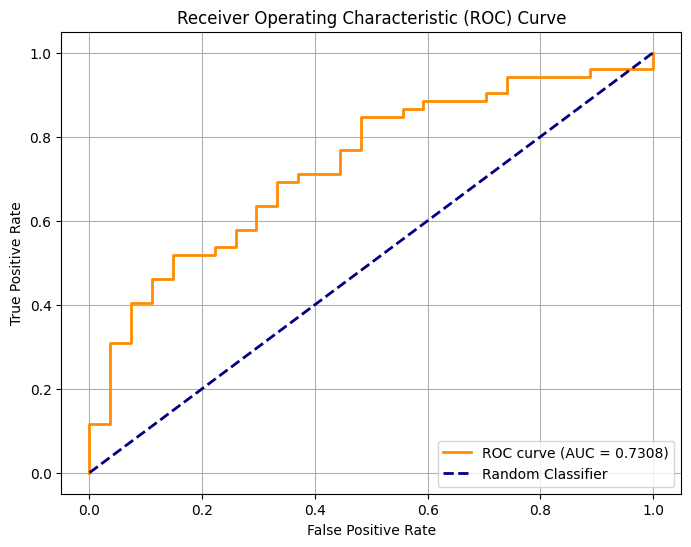

ROC curve plot generated.


In [17]:
import matplotlib.pyplot as plt

# Create a new figure and an axes object for the plot
plt.figure(figsize=(8, 6))

# Plot the ROC curve
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')

# Plot a dashed diagonal line from (0,0) to (1,1) representing a random classifier
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

# Add a title to the plot
plt.title('Receiver Operating Characteristic (ROC) Curve')

# Label the x-axis as 'False Positive Rate' and the y-axis as 'True Positive Rate'
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# Add a legend
plt.legend(loc='lower right')

# Display the plot
plt.grid(True)
plt.show()
print("ROC curve plot generated.")